# Analyse Size in EuXFEL switchyard

In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')

import numpy as _np
import matplotlib.pyplot as _plt
import pymad8 as _m8
import scipy
import pandas as _pd

import XFEL_BPM
import loadXFELdata
import plotXFELdata

initializing ocelot...


### Date and save prefix

In [2]:
date = "2026_07_07"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/Size/" + date + "_EuXFEL_plot"

In [3]:
def getWireTable(mat):
    quad_scan = mat['quad_scan']
    wire_data = mat['quad_scan']['wire'][0][0][0][0]
    d = {}
    col = []
    for key in wire_data.dtype.names:
        if key not in ["quad_strength", "tranfer_matrices"]:
            col.append(key)
            if key == 'measurement_screen':
                d[key] = [name[0] for name in wire_data[key].flatten()]
            else:
                d[key] = wire_data[key].flatten()
    return _pd.DataFrame(d, columns=col)


def getMeasurement(mat, plane='x', screen=0):
    measurement_data = mat['measurement_data']
    pos_x = measurement_data['positions_{}'.format(plane)][0][screen].flatten()
    d = {plane:pos_x}
    for wire in range(5):
        d['wire_{}'.format(wire)] = measurement_data['intensities_{}'.format(plane)][0][screen][:,wire]
    return _pd.DataFrame(d, columns=d.keys())


def getResultTable(mat):
    quad_scan = mat['quad_scan']
    result = mat['result']
    d = {'measurement_screen': [name[0] for name in quad_scan['wire'][0][0][0][0]['measurement_screen'].flatten()]}
    d['sigma_x'] = result['x'][0, 0]['Gaussian'][0][0][0][0]['beamsize'].flatten()*1e6
    d['sigma_y'] = result['y'][0, 0]['Gaussian'][0][0][0][0]['beamsize'].flatten()*1e6
    d['err_sigma_x'] = result['x'][0, 0]['Gaussian'][0][0][0][0]['beamsize_err'].flatten()*1e6
    d['err_sigma_y'] = result['y'][0, 0]['Gaussian'][0][0][0][0]['beamsize_err'].flatten()*1e6
    return _pd.DataFrame(d, columns=d.keys())


def plotMeasurment(mat, screen=0, figsize=[11, 5]):
    df_x = getMeasurement(mat, plane='x', screen=screen)
    df_y = getMeasurement(mat, plane='y', screen=screen)
    x = []
    y = []
    _plt.subplots(1, 2, figsize=figsize, sharey=True)
    _plt.subplot(121)
    for key in df_x.keys():
        if key == 'x':
            x=df_x[key]
        else:
            _plt.plot(x, df_x[key], label=key)
    _plt.ylabel('Intensity at the screen')
    _plt.xlabel(r"$x$ [mm]")
    _plt.legend([r'30 $\rm \mu m$', r'50 $\rm \mu m$', r'10 $\rm \mu m$ crossed', r'10 $\rm \mu m$ crossed', r'20 $\rm \mu m$'])
    _plt.semilogy()
    _plt.subplot(122)
    for key in df_y.keys():
        if key == 'y':
            x=df_y[key]
        else:
            _plt.plot(x, df_y[key], label=key)
    _plt.xlabel(r"$y$ [mm]")
    _plt.semilogy()
    _plt.tight_layout()

### File load

In [4]:
file = 'XFEL_data/Size_data/2023-06-05T154843_quad_scan_proj_TL_OTRBW_1899_TL_OTRBW_1914_TL_OTRBW_1929_TL_wire.mat'
file = 'XFEL_data/Size_data/2023-05-17T213112_quad_scan_proj_T1_OTRBW_2117_T1_OTRBW_2146_T1_OTRBW_2161_T1_OTRBW_2174_T1_wire.mat'
mat = scipy.io.loadmat(file)

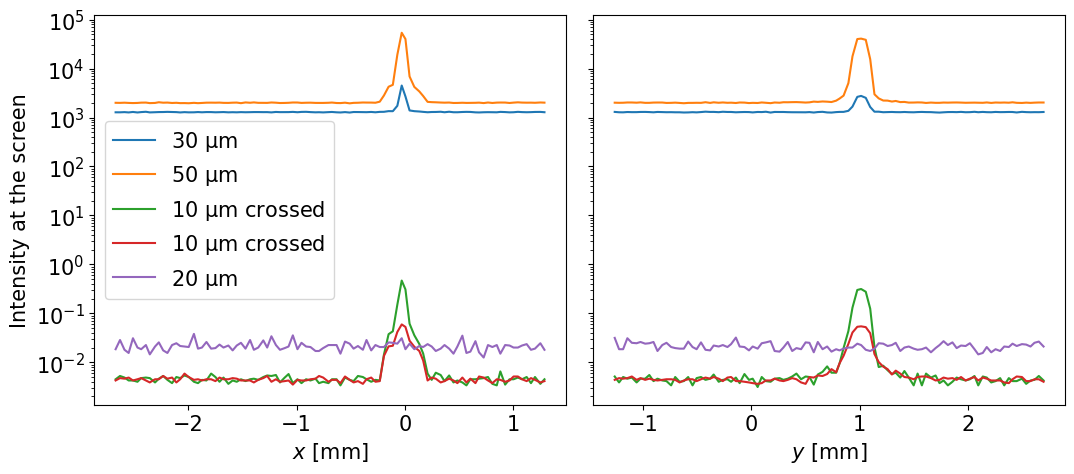

In [5]:
plotMeasurment(mat, screen=0)
_plt.savefig("{}_Example_wire_scan.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [72]:
df_wire = getWireTable(mat)
df_meas_0 = getMeasurement(mat, screen=0)
df_result = getResultTable(mat)

In [6]:
df_wire

,measurement_screen,screen_position,betax_at_screen,betay_at_screen,psix_at_screen,psiy_at_screen
0,OTRBW.2117.T1,19.5,33.15,37.76,45.933803,37.439595
1,OTRBW.2146.T1,48.5,34.64,26.90,93.681464,92.914503
2,OTRBW.2161.T1,63.0,32.23,26.37,113.337183,134.839773
3,OTRBW.2174.T1,76.2,28.19,31.03,145.635157,156.001568
4,OTRBW.2117.T1,19.5,66.74,48.08,27.337822,41.062802
5,OTRBW.2146.T1,48.5,41.36,100.06,57.452426,62.079920
6,OTRBW.2161.T1,63.0,31.51,36.10,76.341126,78.845811
7,OTRBW.2174.T1,76.2,15.53,24.40,115.560259,103.571461


In [7]:
df_meas_0

,x,wire_0,wire_1,wire_2,wire_3,wire_4
0,-2.670723,1280.0,2002.0,0.004500,0.004250,0.0185
1,-2.630039,1279.0,1994.0,0.005250,0.004750,0.0285
2,-2.588682,1291.0,2011.0,0.004875,0.004625,0.0180
3,-2.550330,1272.0,1990.0,0.004250,0.004875,0.0155
4,-2.510631,1301.0,1977.0,0.004250,0.004250,0.0310
...,...,...,...,...,...,...
95,1.124865,1284.0,2013.0,0.005000,0.004125,0.0235
96,1.164486,1290.0,2016.0,0.003750,0.004750,0.0180
97,1.201528,1301.0,2004.0,0.005000,0.004375,0.0190
98,1.251049,1304.0,2032.0,0.003625,0.003875,0.0245


In [73]:
df_result

,measurement_screen,sigma_x,sigma_y,err_sigma_x,err_sigma_y
0,OTRBW.2117.T1,22.749059,50.112166,1.137453,2.505608
1,OTRBW.2146.T1,27.671414,39.709990,1.383571,1.985499
2,OTRBW.2161.T1,32.515966,67.106255,1.625798,3.355313
3,OTRBW.2174.T1,34.927271,89.267931,1.746364,4.463397
4,OTRBW.2117.T1,40.056468,48.003899,2.002823,2.400195
5,OTRBW.2146.T1,35.758012,48.745104,1.787901,2.437255
6,OTRBW.2161.T1,24.364364,28.184034,1.218218,1.409202
7,OTRBW.2174.T1,21.952350,48.400989,1.097617,2.420049


In [85]:
emitx = (df_result.sigma_x*1e-6)**2/df_wire.betax_at_screen

In [86]:
emitx

0    1.561145e-11
1    2.210471e-11
2    3.280447e-11
3    4.327472e-11
4    2.404136e-11
5    3.091478e-11
6    1.883917e-11
7    3.103063e-11
dtype: float64

In [75]:
relat = df_result.err_sigma_x / df_result.sigma_x

In [80]:
(relat*100).to_list()

[5.0, 5.000000000000001, 5.0, 5.0, 5.0, 5.0, 5.000000000000001, 5.0]

In [84]:
_np.mean(df_result.err_sigma_x)

np.float64(1.49996813842793e-06)

In [10]:
quad_scan.dtype.names

('slice_measurement',
 'all_quads',
 'scan_quads',
 'scan_quads_v',
 'common_power_supply_v',
 'all_screens',
 'screen_positions',
 'reference_point',
 'twiss_at_reference_point',
 'beta_functions',
 'wire',
 'screen')

In [11]:
measurement_data.dtype.names

('positions_x',
 'intensities_x',
 'gaussian_fit_params_x',
 'positions_y',
 'intensities_y',
 'gaussian_fit_params_y',
 'cal',
 'spotsize_gauss',
 'spotsizeE_gauss',
 'centerofmass_gauss',
 'centerofmassE_gauss',
 'spotsize_rms',
 'spotsizeE_rms',
 'centerofmass_rms',
 'centerofmassE_rms',
 'intensity',
 'intensityE')

In [12]:
result.dtype.names

('version',
 'seq_ts',
 'seq_id',
 'measurement_id',
 'monitor',
 'gamma_rel',
 'energy',
 'slice_index',
 'bunch_index',
 'preview',
 'x',
 'y',
 'valid_x',
 'valid_y',
 'design',
 'fit_x',
 'fit_y',
 'transfer_matrix',
 'machine',
 'category')

In [18]:
result['x'][0, 0].dtype.names

('Gaussian', 'RMS', 'intensity', 'intensity_err', 'profiles')

In [27]:
result['x'][0, 0]['Gaussian'][0][0].dtype.names

('beamsize', 'beamsize_err', 'centerofmass', 'centerofmass_err')

In [28]:
result['x'][0, 0]['Gaussian'][0][0]['beamsize']

array([[array([[2.27490588e-05],
               [2.76714135e-05],
               [3.25159660e-05],
               [3.49272708e-05],
               [4.00564678e-05],
               [3.57580119e-05],
               [2.43643638e-05],
               [2.19523496e-05]])]], dtype=object)

In [29]:
result['x'][0, 0]['Gaussian'][0][0]['beamsize_err']

array([[array([[1.13745294e-06],
               [1.38357068e-06],
               [1.62579830e-06],
               [1.74636354e-06],
               [2.00282339e-06],
               [1.78790059e-06],
               [1.21821819e-06],
               [1.09761748e-06]])]], dtype=object)

In [42]:
result['gamma_rel'][0, 0]

array([[31898.23874755]])

In [24]:
result[0, 0]['design']['emittance_y']

array([[array([[1.e-06]])]], dtype=object)

In [35]:
result[0, 0]['design'].dtype.names

In [29]:
result.shape

(1, 1)

In [35]:
result[0, 0]['x'].dtype.names

('Gaussian', 'RMS', 'intensity', 'intensity_err', 'profiles')